In [2]:
import torch
import torchvision
from src.vmmdref.VMMDDiagonal1Channel import VMMDDiagonal1Channel
from torch import nn
from torchvision.transforms import transforms

from src.models.autoencoder.resnet.ResNet18AutoEncoder import ResNet18AutoEncoder
from src.models.autoencoder.resnet.ResNet50AutoEncoder import ResNet50AutoEncoder
from src.models.generator.convolution.GeneratorConvLinearMappingBigSigmV2 import GeneratorConvLinearMappingBigSigmV2
from src.vmmdref.VMMDConvLinearMappingRef import VMMDConvLinearMappingRef

In [3]:
import numpy as np
from sklearn.model_selection import ParameterSampler

def generate_hyperparams(n_iter=10, random_state=777):
    """
    Generates a list of dictionaries, each containing a random combination
    of hyperparameters for model tuning.

    :param n_iter:        How many random hyperparameter sets to generate.
    :param random_state:  Seed for reproducibility.
    :return:              A list of dictionaries with hyperparameter configurations.
    """

    # Define your hyperparameter search space
    param_distributions = {
        'batch_size':    [128, 256, 500, 1024],
        'epochs':        [1000, 500, 700, 400],
        'lr':            [0.5, 0.1, 0.05, 0.01, 0.005] ,    # e.g., [1e-4, 1e-3, 1e-2, 1e-1]
        'momentum':      np.linspace(0.8, 0.99, 5),  # e.g., [0.8, 0.85, 0.9, 0.95, 0.99]
        'seed':          [777, 111, 222, 333],
        'weight_decay':  np.logspace(-4, -1, 4), # e.g., [1e-4, 1e-3, 1e-2, 1e-1]
        'latent_size': [64, 256, 512, 1024]
    }

    # Randomly sample n_iter configurations from the above distributions
    sampler = ParameterSampler(param_distributions, n_iter=n_iter, random_state=random_state)

    # Convert the iterator to a list of dictionaries
    param_list = list(sampler)
    return param_list

In [4]:
transform = transforms.Compose(
    [
        transforms.ToTensor(),
 #       transforms.Normalize(mean=[0.4955, 0.4564, 0.4155], std=[0.2568, 0.2523, 0.2580])
     ]
)
dataset = torchvision.datasets.CIFAR10(root='../../data', train=True, download=True,
                                       transform=transform)
cats_dataset = [(img, label) for (img, label) in dataset if label == 3]

Files already downloaded and verified


KeyboardInterrupt: 

In [14]:
print("Hello")

Hello


In [ ]:
from src.models.generator.linear_mapping.GeneratorLinearMappingTanh import GeneratorLinearMappingTanh
from src.vmmdref.VMMDLinearMappingRef import VMMDLinearMappingRef

hyperparameter_list = generate_hyperparams(n_iter=10, random_state=777)
for i in range(1, len(hyperparameter_list)):
    vmmd =VMMDLinearMappingRef(
        filename=f"linear_mapping_hypparam_1_{i}",
        weight_decay=hyperparameter_list[i]['weight_decay'],
        seed=hyperparameter_list[i]['seed'],
        momentum=hyperparameter_list[i]['momentum'],
        lr=0.5,
        epochs=100,
        batch_size=hyperparameter_list[i]['batch_size'],
        path_to_directory="")
    noise_dim = 256
    vmmd.fit(cats_dataset, ResNet18AutoEncoder(), GeneratorLinearMappingTanh(noise_dim))

In [1]:
from src.models.generator.linear_mapping.GeneratorLinearMappingTanh import GeneratorLinearMappingTanh
from src.vmmdref.VMMDLinearMappingRef import VMMDLinearMappingRef

hyperparameter_list = generate_hyperparams(n_iter=9, random_state=777)
for i in range(1, len(hyperparameter_list)):
    vmmd =VMMDLinearMappingRef(
        filename=f"linear_mapping_hypparam_1_{i}",
        weight_decay=hyperparameter_list[i]['weight_decay'],
        seed=hyperparameter_list[i]['seed'],
        momentum=hyperparameter_list[i]['momentum'],
        lr=hyperparameter_list[i]['lr'],
        epochs=hyperparameter_list[i]['epochs'],
        batch_size=hyperparameter_list[i]['batch_size'],
        path_to_directory="/home/i40/enciup/V-GAN/experiments/remote")
    noise_dim = hyperparameter_list[i]['latent_size']
    vmmd.fit(cats_dataset, ResNet50AutoEncoder(), GeneratorLinearMappingTanh(noise_dim))

NameError: name 'generate_hyperparams' is not defined

In [3]:
from src.models.generator.diagonal_matrix.three_channels.GeneratorThreeChannel import GeneratorThreeChannel
from src.vmmdref.VMMDDiagonal3Channel import VMMDDiagonal3Channel

hyperparameter_list = generate_hyperparams(n_iter=10, random_state=777)
for i in range(len(hyperparameter_list)):
    vmmd =VMMDDiagonal3Channel(
        filename=f"three_channel__hypparam_2_{i}",
        weight_decay=hyperparameter_list[i]['weight_decay'],
        seed=hyperparameter_list[i]['seed'],
        momentum=hyperparameter_list[i]['momentum'],
        lr=hyperparameter_list[i]['lr'],
        epochs=10000,
        batch_size=hyperparameter_list[i]['batch_size'],
        path_to_directory="/home/i40/enciup/V-GAN/experiments/remote")
    noise_dim = hyperparameter_list[i]['latent_size']
    vmmd.fit(cats_dataset, ResNet18AutoEncoder(), GeneratorThreeChannel(noise_dim))

NameError: name 'cats_dataset' is not defined

Count:  500 PVal:  1.0
The show option has been depricated due to lack of utility


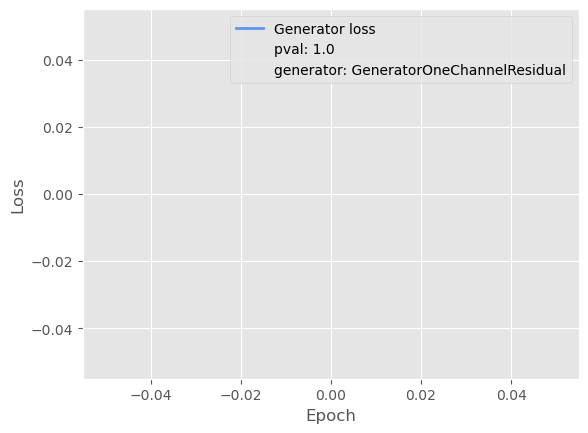

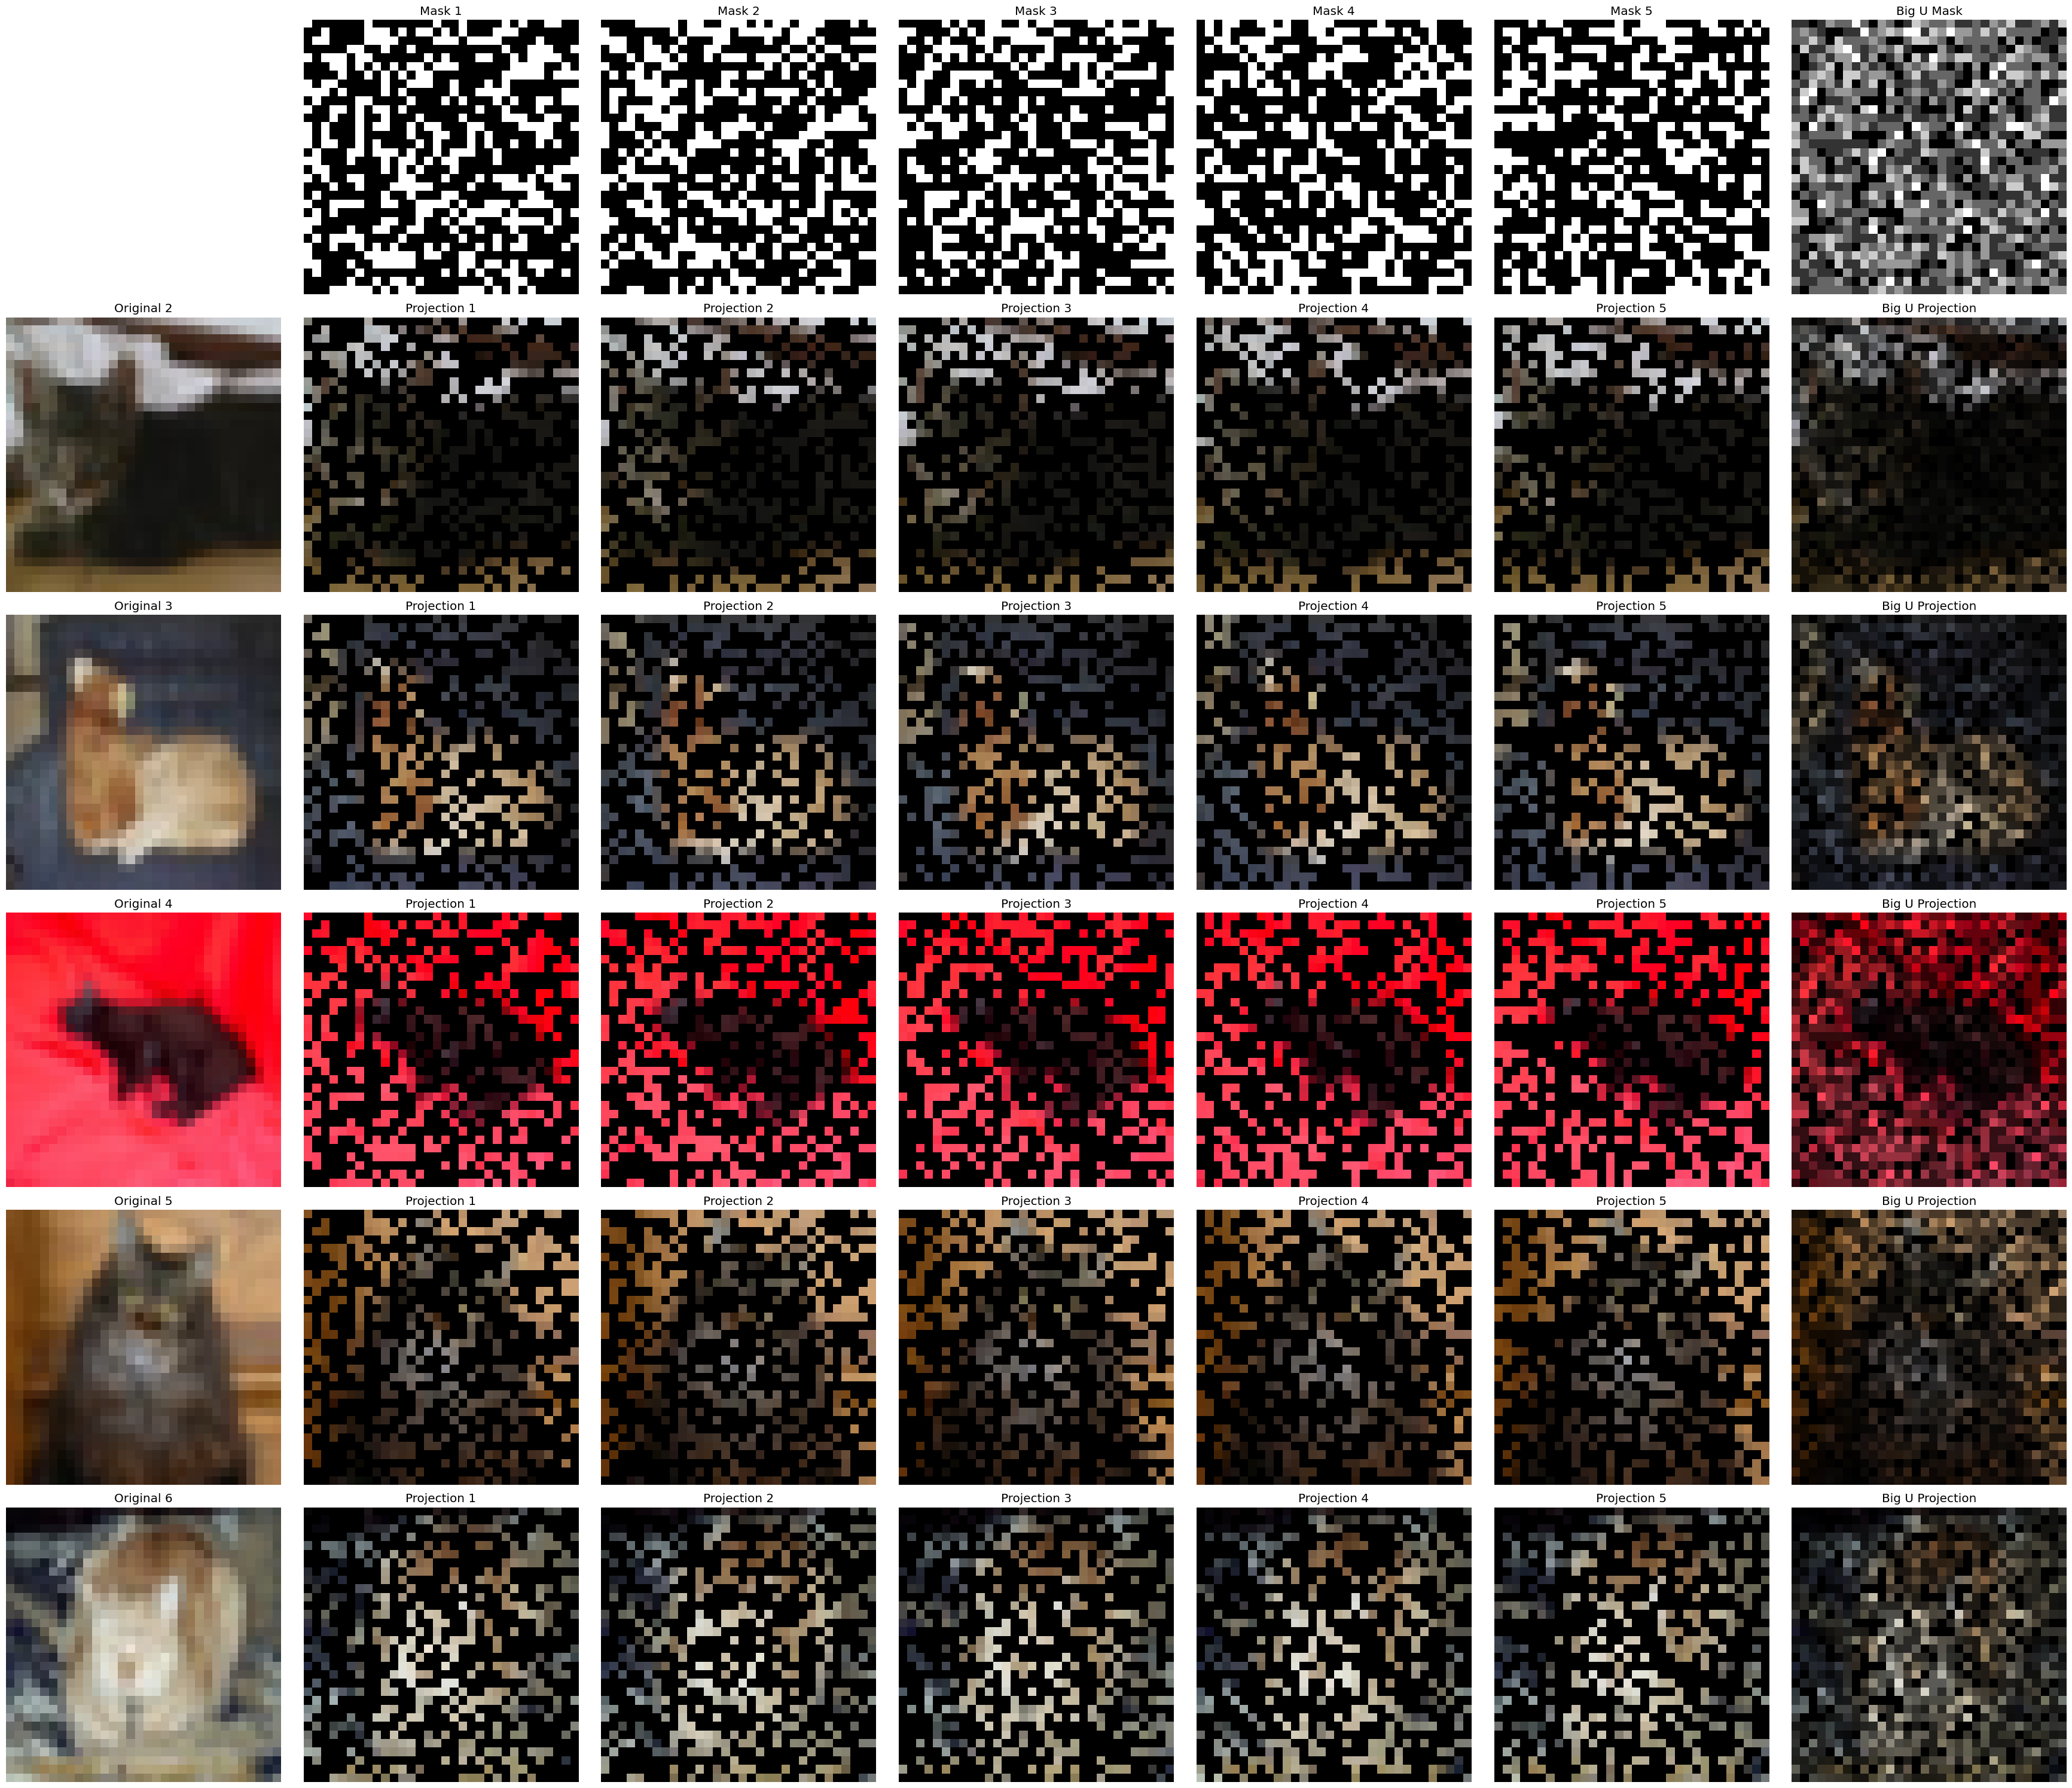

Epoch 0 of 300


Average loss in the epoch: 0.043435869738459594
Epoch 1 of 300


Average loss in the epoch: 0.044994451105594635
Epoch 2 of 300


Average loss in the epoch: 0.04569774679839611
Epoch 3 of 300


Average loss in the epoch: 0.04687820076942444
Epoch 4 of 300


...

Average loss in the epoch: 0.04138600286096335
Epoch 36 of 300


Average loss in the epoch: 0.04268450774252414
Epoch 37 of 300


Average loss in the epoch: 0.042945459857583045
Epoch 38 of 300


Average loss in the epoch: 0.04103629440069199
Epoch 39 of 300


  0%|          | 0/10 [00:00<?, ?it/s]

In [ ]:
from src.models.generator.diagonal_matrix.one_channel.GeneratorOneChannelResidual import GeneratorOneChannelResidual

hyperparameter_list = generate_hyperparams(n_iter=5, random_state=777)
for i in range(len(hyperparameter_list)):
    vmmd =VMMDDiagonal1Channel(
        filename=f"one_channel_hypparam_1_{i}",
        weight_decay=hyperparameter_list[i]['weight_decay'],
        seed=hyperparameter_list[i]['seed'],
        momentum=hyperparameter_list[i]['momentum'],
        lr=0.5,
        epochs=300,
        batch_size=hyperparameter_list[i]['batch_size'],
        path_to_directory="/home/i40/enciup/V-GAN/experiments/remote")
    noise_dim = hyperparameter_list[i]['latent_size']
    vmmd.fit(cats_dataset, ResNet18AutoEncoder(), GeneratorOneChannelResidual(noise_dim))

Count:  500 PVal:  1.0
The show option has been depricated due to lack of utility


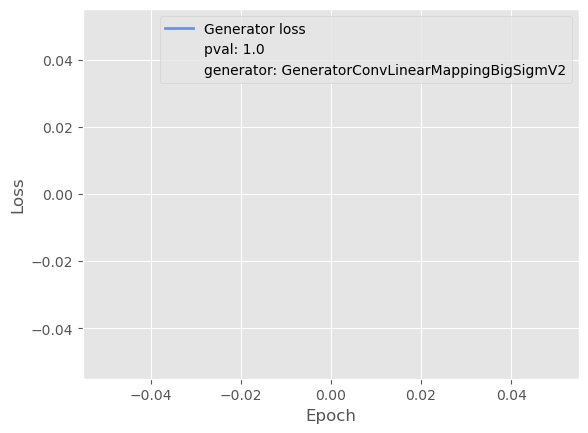

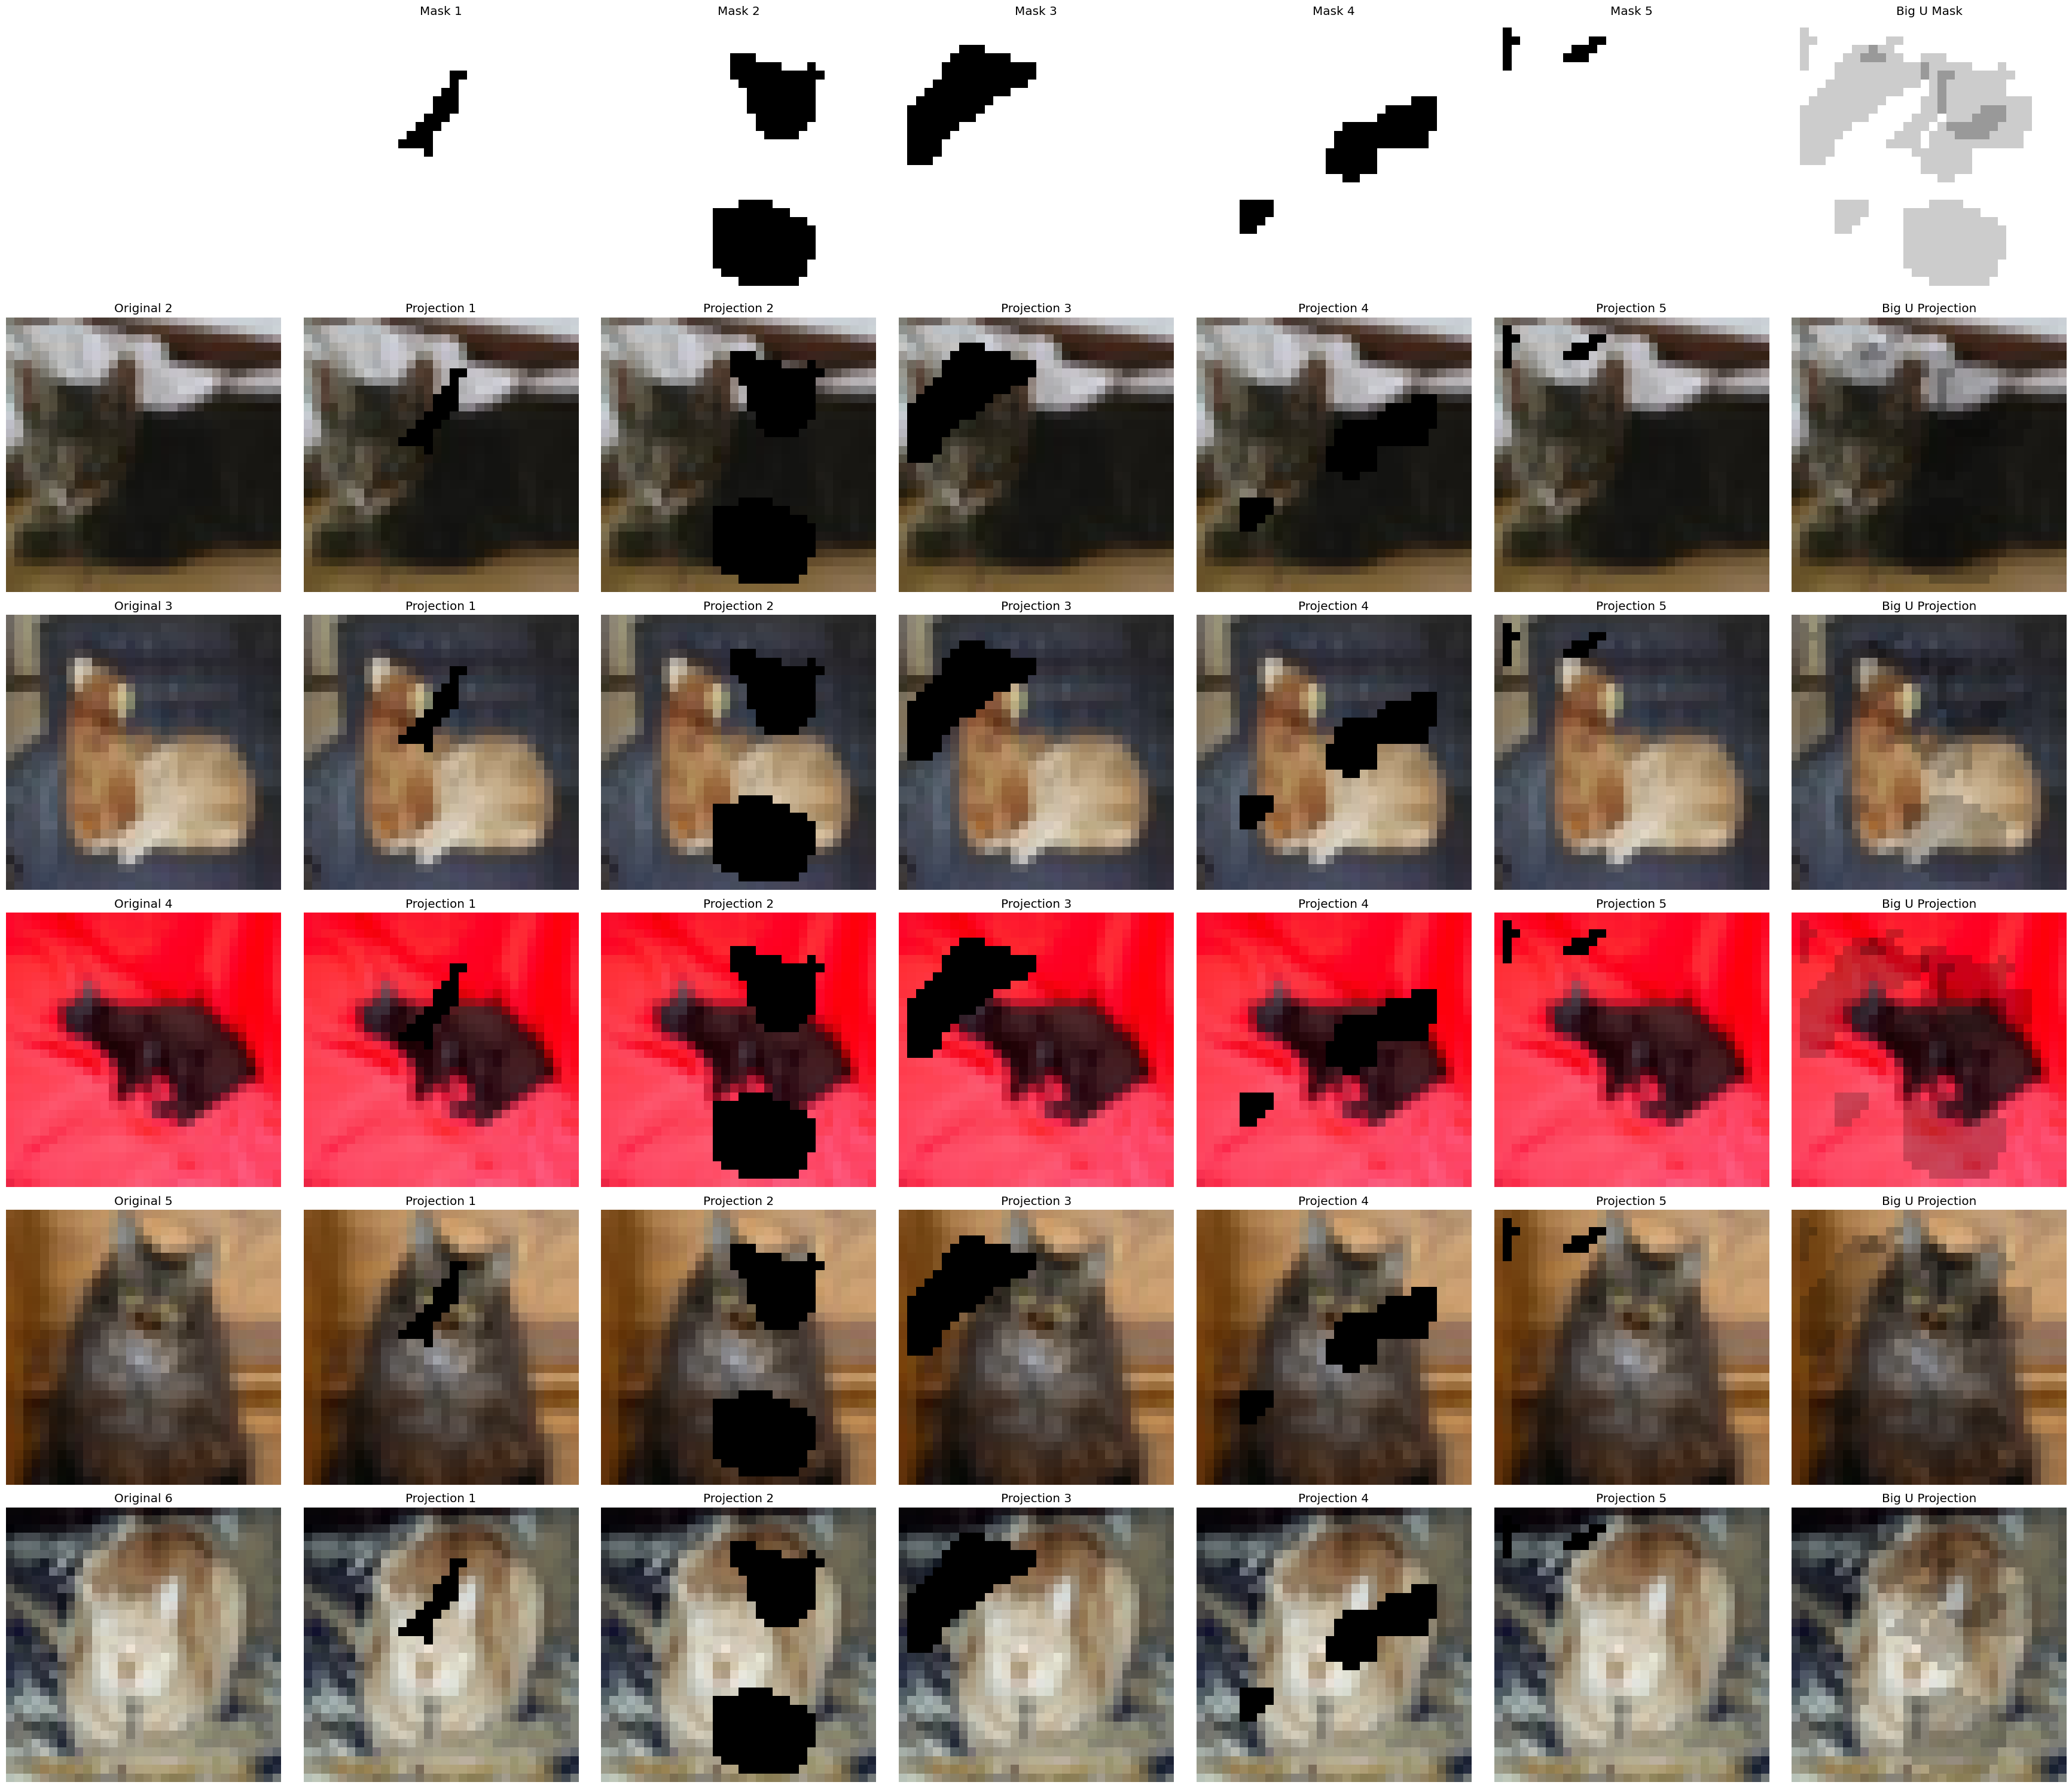

Epoch 0 of 500


Average loss in the epoch: 0.04288705289363861
Epoch 1 of 500


Average loss in the epoch: 0.04240537881851197
Epoch 2 of 500


Average loss in the epoch: 0.04195689260959625
Epoch 3 of 500


Average loss in the epoch: 0.04129565432667732
Epoch 4 of 500


...

Average loss in the epoch: 0.03914980292320252
Epoch 8 of 500


Average loss in the epoch: 0.038564293459057805
Epoch 9 of 500


Average loss in the epoch: 0.03790658004581928
Epoch 10 of 500


Average loss in the epoch: 0.037653415650129314
Epoch 11 of 500


 70%|███████   | 7/10 [00:02<00:00,  3.48it/s]

In [ ]:
from src.models.generator.convolution.GeneratorConvLinearMappingBigSigmV3 import GeneratorConvLinearMappingBigSigmV3

hyperparameter_list = generate_hyperparams(n_iter=10, random_state=777)

for i in range(len(hyperparameter_list)):
    vmmd = VMMDConvLinearMappingRef(
        filename=f"conv_hypparam_tuning_1_{i}",
        weight_decay=hyperparameter_list[i]['weight_decay'],
        seed=hyperparameter_list[i]['seed'],
        momentum=hyperparameter_list[i]['momentum'],
        lr=hyperparameter_list[i]['lr'],
        epochs=hyperparameter_list[i]['epochs'],
        batch_size=hyperparameter_list[i]['batch_size'],
        path_to_directory="/home/i40/enciup/V-GAN/experiments/remote")
    noise_dim = torch.tensor([hyperparameter_list[i]['latent_size'], 1, 1])
    vmmd.fit(cats_dataset, ResNet18AutoEncoder(), GeneratorConvLinearMappingBigSigmV2(noise_dim))